In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

In [29]:
df = pd.read_csv("datos/datos.csv")
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

In [30]:
columnas = ["revenue", "copiessold", "reviewscore"] # vamos a basarnos en estas 3 columnas que son mas descriptivas de "exito"
df = df.dropna(subset=["release_date","genres", "price"]+ columnas)
#sacamos el mes y mapeamos para hacerlo mas facil de entender
df["month"] = df["release_date"].dt.month
"""
mes_map = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
df["month_name"] = df["month"].map(mes_map)
"""

'\nmes_map = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}\ndf["month_name"] = df["month"].map(mes_map)\n'

In [31]:
lista = ["genres", "categories"]
cuantitativas = ["price"]
df["month"] = df["month"].astype(str)
cualitativas = ["month"]

originales = df[cuantitativas + cualitativas + lista].copy()

df_cuantitativo = originales[cuantitativas].copy()
df_lista = originales[lista].copy()
df_cualitativo = originales[cualitativas].copy()

df_binarizado = pd.DataFrame(index=df_lista.index)
for columnas in lista:
    listas = df_lista[columnas].fillna("").astype(str).str.split(",")
    mlb = MultiLabelBinarizer()
    binarizado = mlb.fit_transform(listas)
    temp = pd.DataFrame(binarizado, columns=mlb.classes, index=df_lista.index).add_prefix(f"{columnas}_")
    df_binarizado = pd.concat([df_binarizado, temp], axis=1)

In [32]:
df_cuantitativo = df[cuantitativas]
df_para_pca = pd.concat([df_cuantitativo, df_binarizado], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_para_pca)
X_scaled = pd.DataFrame(X_scaled, columns=df_para_pca.columns, index=df_para_pca.index)
pca = PCA(n_components=min(27, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_.sum()
print(f"Varianza explicada por las primeras {pca.n_components_} componentes principales: {explained:.3%}")

#convertimos el df 
column_names_pca = [f"PCA_{i}" for i in range(X_pca.shape[1])]
df_pca_final = pd.DataFrame(X_pca, columns=column_names_pca, index=df.index)

Varianza explicada por las primeras 27 componentes principales: 1.270%


In [33]:
df_cualitativo = df[["month"]].copy()
encoder = OneHotEncoder(
    min_frequency=100,
    handle_unknown='ignore',
    dtype=np.float32,
    drop=None
)

mes_resultado = encoder.fit_transform(df_cualitativo)
columnas_mes = encoder.get_feature_names_out(df_cualitativo.columns)
df_mes = pd.DataFrame(mes_resultado.toarray(), columns=columnas_mes, index=df_cualitativo.index)

In [34]:
#unimos los meses limpios, el pca (resumen de precio y generos)
columnas = ["revenue", "copiessold", "reviewscore"]
df_final = pd.concat([df_mes, df_pca_final], axis=1)

#entrenamos la regresion para buscar el mejor mes
resultados = {}
columnas_meses = [col for col in df_final.columns if col.startswith("month_")]
for columna in columnas:
    y = df[columna]
    modelo = LinearRegression(fit_intercept=False) #PONEMOS ESTO EN FALSO POR EL ONE HOT
    modelo.fit(df_final, y)
    resultados[columna] = pd.Series(modelo.coef_, index=df_final.columns)[columnas_meses]

In [52]:
coefs = pd.DataFrame(resultados)

coefs["mes_num"] = coefs.index.str.extract("(\d+)", expand=False).astype(int)
mes_coefs = coefs.sort_values("mes_num")

mapa_meses = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
mes_coefs.index = mes_coefs["mes_num"].map(mapa_meses)
mes_coefs = mes_coefs.drop(columns=["mes_num"])

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\alons\AppData\Local\Temp\ipykernel_13260\623733235.py:3: SyntaxWarning: invalid escape sequence '\d'
  coefs["mes_num"] = coefs.index.str.extract("(\d+)", expand=False).astype(int)


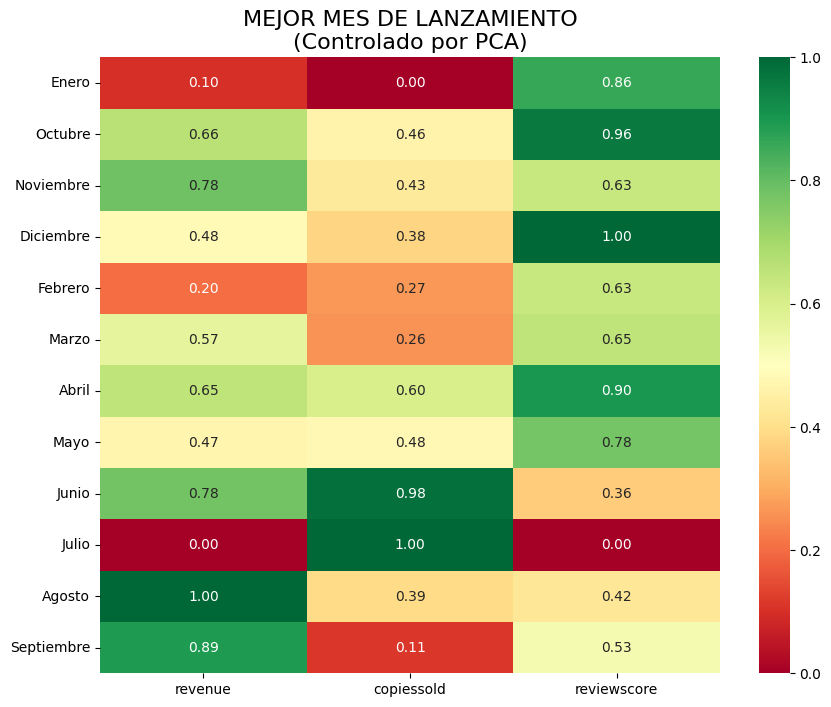

In [53]:
month_map_reverse = {
    '1': 'Enero',
    '2': 'Febrero',
    '3': 'Marzo',
    '4': 'Abril',
    '5': 'Mayo',
    '6': 'Junio',
    '7': 'Julio',
    '8': 'Agosto',
    '9': 'Septiembre',
    '10': 'Octubre',
    '11': 'Noviembre',
    '12': 'Diciembre'
}
scaler_plot = MinMaxScaler()
df_plot = pd.DataFrame(scaler_plot.fit_transform(coefs), 
                       index=coefs.index, columns=coefs.columns)

df_plot.index = df_plot.index.str.replace('month_', '', regex=False)
df_plot = df_plot.drop(columns=['mes_num'])
df_plot.index = df_plot.index.map(month_map_reverse)
plt.figure(figsize=(10, 8))
sns.heatmap(df_plot, annot=True, cmap="RdYlGn", fmt=".2f")
plt.title(f"MEJOR MES DE LANZAMIENTO\n(Controlado por PCA)", fontsize=16)
plt.show()

En el mes de Junio tenemos SUMMER SALES y Diciembre las WINTER SAlES, son buenos para aumentar el volumen de ventas pero no tanto de revenue, ya que bajan los precios. 

En julio pareciera que se vende mucho pero no ganas tanto (baja de precios) y peores notas se reciben. (?)

Enero parece el mes mas flojo de todos. 

Para maximizar review score: Febrero y octubre. 

Para maximizar jugadores: Julio y Junio, mayores copias vendidas. 

Para maximizar ganancias: Agosto. 

In [37]:
#SIMULACION DE UN POSIBLE VENDEDOR

#re entrenamiento
modelos = {} 
columnas = ["revenue", "copiessold", "reviewscore"]

for columna in columnas:
    y = df[columna]
    #modelo para cada objetivo
    m = LinearRegression(fit_intercept=False)
    m.fit(df_final, y)
    modelos[columna] = m

In [38]:
def simular_venta(mis_generos, mis_categorias, mi_precio):
    df_binario = pd.DataFrame(0, index=[0], columns=df_binarizado.columns)
    tags = mis_generos + mis_categorias
    for i in tags: 
        for col in df_binario.columns:
            if i in col:
                df_binario.at[0, col] = 1
    #pca precio + binarios
    df_pca_temp = pd.DataFrame(0, index=[0], columns=df_para_pca.columns)
    df_pca_temp.at[0, "price"] = mi_precio
    df_pca_temp.update(df_binario)

    #escalamos
    X_temp_scaled = scaler.transform(df_pca_temp)
    X_temp_resultado = pca.transform(X_temp_scaled)
    df_predict = pd.DataFrame(X_temp_resultado, columns=[f"PCA_{i}" for i in range(X_temp_resultado.shape[1])])

    resultados = []
    meses_cols = [c for c in df_final.columns if "month_" in c]
    #rango de cada mes
    for mes in range(1, 13):
        fila = pd.DataFrame(0, index=[0], columns=df_final.columns)
        fila.update(df_predict)
        col_mes = [c for c in columnas_meses if f"month_{mes}" in c or f"_{mes}.0" in c]
        if col_mes:
            fila[col_mes[0]] = 1
        #sacamos los 3 modelos
        pred_revenue = modelos["revenue"].predict(fila)[0]
        pred_copiessold = modelos["copiessold"].predict(fila)[0]
        pred_reviewscore = modelos["reviewscore"].predict(fila)[0]

        resultados.append({
            "month": mes,
            "predicted_revenue": pred_revenue,
            "predicted_copiessold": pred_copiessold,
            "predicted_reviewscore": pred_reviewscore
        })
    return pd.DataFrame(resultados)

In [39]:
#SIMULACIOn
mis_generos = ["Action"]
mis_categorias = ["Single-player","Multi-player"]
mi_precio = 14.99

simulacion_resultados = simular_venta(mis_generos, mis_categorias, mi_precio)

simulacion_resultados["month_name"] = simulacion_resultados["month"].map(mapa_meses)
simulacion_resultados = simulacion_resultados.set_index("month_name")
#sacamos ganadores
mejor_revenue = simulacion_resultados["predicted_revenue"].idxmax()
mejor_copiessold = simulacion_resultados["predicted_copiessold"].idxmax()
display(simulacion_resultados[["predicted_revenue", "predicted_copiessold", "predicted_reviewscore"]])

print(f"Mejor mes por revenue: {mejor_revenue}")
print(f"Mejor mes por copiessold: {mejor_copiessold}")


C:\Users\alons\AppData\Local\Temp\ipykernel_13260\1278351718.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14.99' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_pca_temp.at[0, "price"] = mi_precio
C:\Users\alons\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
C:\Users\alons\AppData\Local\Temp\ipykernel_13260\1278351718.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.24901052]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  fila.update(df_predict)
C:\Users\alons\AppData\Local\Temp\ipykernel_13260\1278351718.py:23: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a

,predicted_revenue,predicted_copiessold,predicted_reviewscore
month_name,,,
Enero,233858.727611,47512.407922,71.489991
Febrero,244302.868254,55182.992441,70.985967
Marzo,281547.516647,54898.411859,71.021085
Abril,290306.474254,64617.341837,71.577009
Mayo,271456.552484,61204.579829,71.299767
Junio,303629.150958,75569.083776,70.380558
Julio,223513.565933,76115.941121,69.585435
Agosto,326228.069599,58727.155352,70.524599
Septiembre,315362.931001,50721.189633,70.756312


Mejor mes por revenue: Agosto
Mejor mes por copiessold: Julio


Por mas que variemos los parametros nos dan los mismos resultados, pero puede que sea un efecto adverso que nos provocan las grandes empresas que venden millones de copias, si intentamos una forma pensada para indies dejando de lado esos outliers quizas nos muestre otra realidada para los mas indies

In [40]:
#intento sin GRANDES EMPRESAS
df = pd.read_csv("datos/datos.csv")
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
columnas_objetivo = ["revenue", "copiessold", "reviewscore"]

df = df.dropna(subset=["release_date", "price", "genres", "categories"] + columnas_objetivo)
df["month"] = df["release_date"].dt.month.astype(str)

#vamos a filtrar las grandes empresas
limite_revenue = df["revenue"].quantile(0.95)
limite_copiessold = df["copiessold"].quantile(0.95)
print("los juegos que ganan mas de ", limite_revenue, " o venden mas de ", limite_copiessold, " son considerados grandes empresas, en esta simulacion")

los juegos que ganan mas de  1173717.5499999956  o venden mas de  252884.74999999997  son considerados grandes empresas, en esta simulacion


In [41]:
df_filtrado = df[
    (df["revenue"] < limite_revenue) & 
    (df["copiessold"] < limite_copiessold)
].copy()
print(f"total de juegos despues del filtrado: {len(df_filtrado)}")

total de juegos despues del filtrado: 21675


In [42]:
columnas_lista = ["genres", "categories"]
columnas_cuantitativas = ["price"]

df_binarizado_total = pd.DataFrame(index=df_filtrado.index)
df_listas = df_filtrado[columnas_lista].copy()

for columna in columnas_lista:
    listas = df_listas[columna].fillna("").astype(str).str.split(";")
    mlb = MultiLabelBinarizer()
    datos_binarizados = mlb.fit_transform(listas)
    df_temp = pd.DataFrame(
        datos_binarizados, 
        columns=mlb.classes_, 
        index=df_filtrado.index
    ).add_prefix(f"{columna}_")
    
    df_binarizado_total = pd.concat([df_binarizado_total, df_temp], axis=1)

In [43]:
df_cuantitativo = df_filtrado[columnas_cuantitativas]
df_para_pca = pd.concat([df_cuantitativo, df_binarizado_total], axis=1)
scaler = MinMaxScaler()

datos_escalados = scaler.fit_transform(df_para_pca)
df_escalado = pd.DataFrame(
    datos_escalados, 
    columns=df_para_pca.columns, 
    index=df_filtrado.index
)

In [44]:
#pca
pca = PCA(n_components=min(27, df_escalado.shape[1]))
resultado_pca = pca.fit_transform(df_escalado)
columnas_pca = [f"PCA_{i}" for i in range(resultado_pca.shape[1])]

df_pca_final = pd.DataFrame(
    resultado_pca, 
    columns=columnas_pca, 
    index=df_filtrado.index
)
encoder = OneHotEncoder(
    min_frequency=100, 
    handle_unknown="ignore", 
    sparse_output=False, 
    drop=None 
)

meses_encoded = encoder.fit_transform(df_filtrado[["month"]])
nombres_columnas_meses = encoder.get_feature_names_out(["month"])

df_meses_final = pd.DataFrame(
    meses_encoded, 
    columns=nombres_columnas_meses, 
    index=df_filtrado.index
)

In [45]:
df_entrenamiento = pd.concat([df_meses_final, df_pca_final], axis=1)
resultados_finales = {}
columnas_de_meses = [col for col in df_entrenamiento.columns if "month_" in col]
for objetivo in columnas_objetivo:
    y = df_filtrado[objetivo]
    modelo = LinearRegression(fit_intercept=False)
    modelo.fit(df_entrenamiento, y)
    coeficientes = pd.Series(modelo.coef_, index=df_entrenamiento.columns)
    resultados_finales[objetivo] = coeficientes[columnas_de_meses]

In [49]:
df_grafico = pd.DataFrame(resultados_finales)
df_grafico["mes_num"] = df_grafico.index.str.extract("(\d+)", expand=False).astype(int)
df_grafico = df_grafico.sort_values("mes_num")
mapa_meses = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto", 
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

df_grafico.index = df_grafico["mes_num"].map(mapa_meses)
df_grafico = df_grafico.drop(columns=["mes_num"])
scaler_grafico = MinMaxScaler()
datos_grafico_norm = scaler_grafico.fit_transform(df_grafico)
df_heatmap = pd.DataFrame(
    datos_grafico_norm, 
    index=df_grafico.index, 
    columns=df_grafico.columns
)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\alons\AppData\Local\Temp\ipykernel_13260\1194213565.py:2: SyntaxWarning: invalid escape sequence '\d'
  df_grafico["mes_num"] = df_grafico.index.str.extract("(\d+)", expand=False).astype(int)


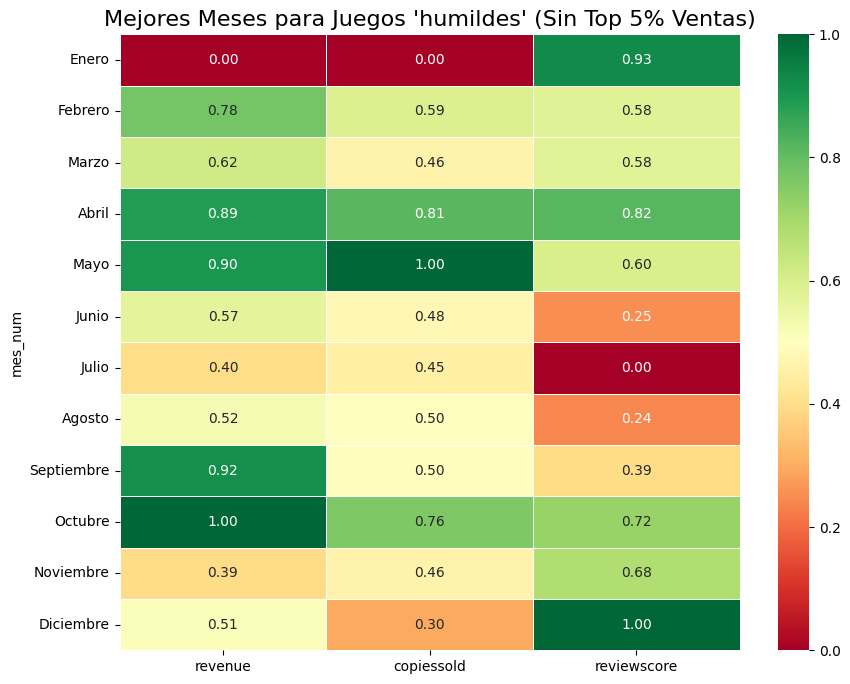

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_heatmap, 
    annot=True, 
    cmap="RdYlGn",
    fmt=".2f",
    linewidths=.5
)
plt.title("Mejores Meses para Juegos 'humildes' (Sin Top 5% Ventas)", fontsize=16)
plt.yticks(rotation=0) 
plt.show()